In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Load Dollars Bars
path = Path("../data/es_dollar_bars.csv")

if not path.exists():
    raise FileNotFoundError(
        f"File not found: {path}"
    )

bars = pd.read_csv(path, parse_dates=["timestamp"])
bars = bars.sort_values("timestamp").reset_index(drop=True)

print("Rows:", len(bars))
print("Start:", bars["timestamp"].min())
print("End:", bars["timestamp"].max())


display(bars.head())

Rows: 149
Start: 2013-09-01 17:19:56.232000
End: 2013-09-03 13:49:06.359000


,ticks,open,high,low,close,volume,dollar_value,timestamp
0,2837,1640.25,1642.0,1639.00,1640.50,12342.0,1.012227e+09,2013-09-01 17:19:56.232
1,3224,1640.25,1642.0,1639.75,1640.75,12303.0,1.009461e+09,2013-09-01 19:09:34.288
2,3396,1640.75,1643.5,1640.75,1642.50,12292.0,1.009253e+09,2013-09-01 20:22:59.983
3,4190,1642.50,1644.0,1640.25,1643.00,12293.0,1.009345e+09,2013-09-02 00:00:47.925
4,4706,1643.00,1644.5,1642.00,1643.50,12283.0,1.009180e+09,2013-09-02 02:00:46.464


In [3]:
# close price series
close = bars.set_index("timestamp")["close"].sort_index()
display(close.head())

timestamp
2013-09-01 17:19:56.232    1640.50
2013-09-01 19:09:34.288    1640.75
2013-09-01 20:22:59.983    1642.50
2013-09-02 00:00:47.925    1643.00
2013-09-02 02:00:46.464    1643.50
Name: close, dtype: float64

In [4]:
# daily volatility
def get_daily_volatility(close, span=100):
    idx = close.index.searchsorted(
        close.index - pd.Timedelta(days=1)
    )
    
    idx = idx[idx > 0]

    prev_idx = pd.Series(
      close.index[idx - 1],
      index=close.index[close.shape[0] - idx.shape[0]:]
    )

    daily_ret = (
      close.loc[prev_idx.index].values /
      close.loc[prev_idx.values].values
      - 1
    )

    daily_ret = pd.Series(
      daily_ret,
      index=prev_idx.index
    )

    return daily_ret.ewm(span=span).std()

In [ ]:
# Calculate and display daily volatility
daily_vol = get_daily_volatility(close, span=100)

print("Daily volatility observations:", daily_vol.notna().sum())
display(daily_vol.dropna().head())

Daily volatility observations: 133


timestamp
2013-09-02 21:53:56.628    0.000541
2013-09-03 00:12:57.042    0.000383
2013-09-03 02:02:41.206    0.000312
2013-09-03 02:25:43.889    0.000790
2013-09-03 02:58:19.615    0.000760
dtype: float64

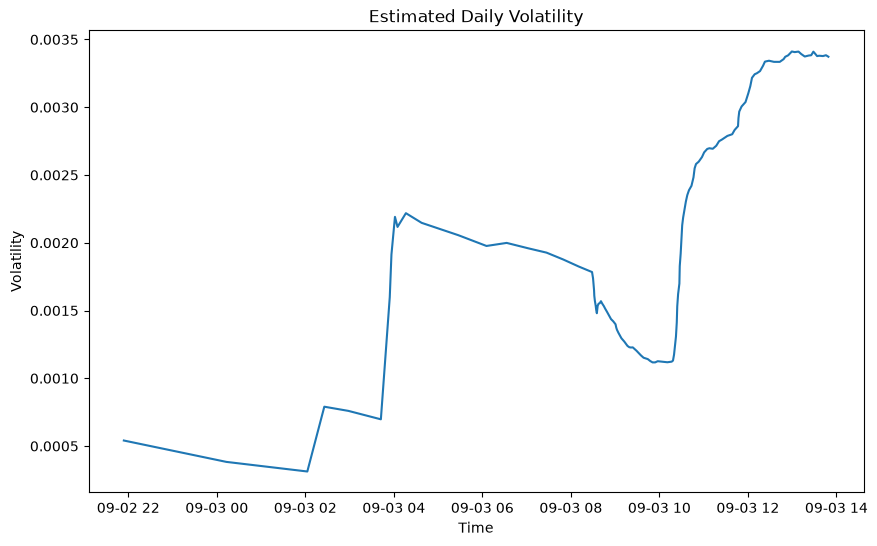

In [6]:
# plot daily volatility
plt.figure(figsize=(10, 6))
plt.plot(daily_vol.index, daily_vol)
plt.title("Estimated Daily Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

### CUSUM Filter
Cusum identifies points where cumulative returns move far enough away from sero to count as an event

In [7]:
# CUSUM function
def cusum_filter(close, threshold):
    log_ret = np.log(close).diff().dropna()

    s_pos, s_neg = 0, 0
    events = []

    for t in log_ret.index:
        if t not in threshold.index:
            continue

        h = threshold.loc[t]

        if pd.isna(h) or h <= 0:
            continue

        value = log_ret.loc[t]

        s_pos = max(0, s_pos + value)
        s_neg = min(0, s_neg + value)

        if s_pos > h:
            events.append(t)
            s_pos = 0
        elif s_neg < -h:
            events.append(t)
            s_neg = 0

    return pd.DatetimeIndex(events)

In [8]:
# Align volatility and get CUSUM events
threshold = daily_vol.reindex(close.index, method='ffill')

t_events = cusum_filter(close, threshold)

print("CUSUM events:", len(t_events))
print(t_events[:10])

CUSUM events: 13
DatetimeIndex(['2013-09-03 00:12:57.042000', '2013-09-03 03:54:27.751000',
               '2013-09-03 07:49:37.527000', '2013-09-03 08:34:19.184000',
               '2013-09-03 08:51:34.336000', '2013-09-03 09:02:26.499000',
               '2013-09-03 09:06:21.906000', '2013-09-03 09:19:07.718000',
               '2013-09-03 09:38:33.409000', '2013-09-03 10:18:25.548000'],
              dtype='datetime64[us]', freq=None)


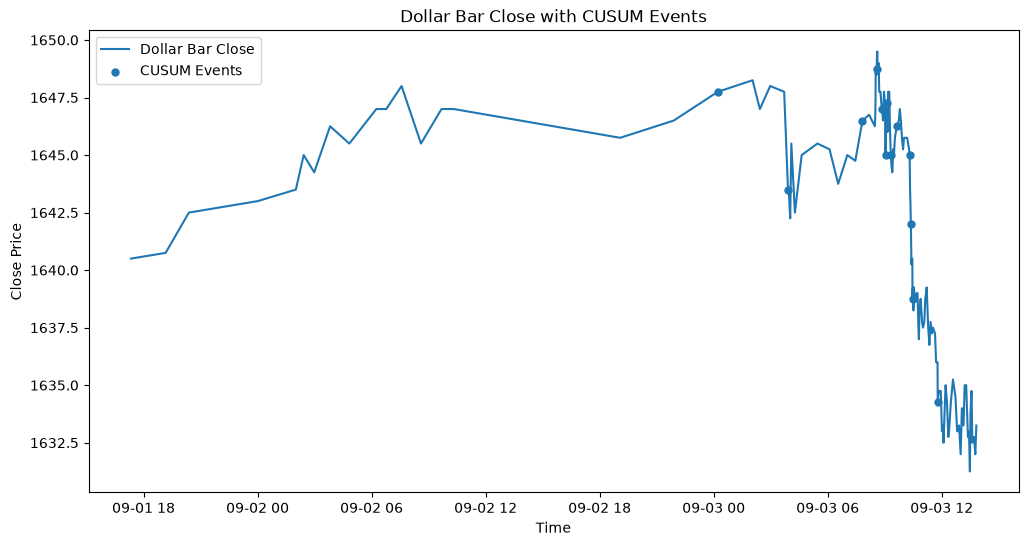

In [9]:
# Plot CUSUM events

plt.figure(figsize=(12, 6))
plt.plot(close.index, close.values, label="Dollar Bar Close")

if len(t_events) > 0:
    plt.scatter(
      t_events,
      close.loc[t_events],
      s=25,
      label="CUSUM Events"
    )

plt.title("Dollar Bar Close with CUSUM Events")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [21]:
def add_vertical_barrier(t_events, close, num_hours=6):
    barrier_positions = close.index.searchsorted(
        t_events + pd.Timedelta(hours=num_hours)
    )

    valid = barrier_positions < close.shape[0]

    barrier_positions = barrier_positions[valid]
    valid_events = t_events[valid]

    return pd.Series(
        close.index[barrier_positions],
        index=valid_events
    )

In [23]:
t1 = add_vertical_barrier(
    t_events,
    close,
    num_hours=6
)

print("Events with valid vertical barriers:", len(t1))
display(t1.head())

Events with valid vertical barriers: 2


2013-09-03 00:12:57.042   2013-09-03 06:32:56.811
2013-09-03 03:54:27.751   2013-09-03 09:57:45.223
Name: timestamp, dtype: datetime64[us]

In [24]:
trgt = daily_vol.reindex(t_events, method="ffill").dropna()

common_events = trgt.index.intersection(t1.index)

trgt = trgt.loc[common_events]
t1 = t1.loc[common_events]

print("Usable events:", len(common_events))
display(trgt.head())

Usable events: 2


2013-09-03 00:12:57.042    0.000383
2013-09-03 03:54:27.751    0.001599
dtype: float64

In [25]:
def apply_triple_barrier(close, t_events, t1, trgt, pt_sl=(1, 1)):
    records = []

    pt_mult, sl_mult = pt_sl

    for t0 in t_events:
        if t0 not in t1.index or t0 not in trgt.index:
            continue

        vertical_time = t1.loc[t0]
        target = trgt.loc[t0]

        path = close.loc[t0:vertical_time]

        if len(path) < 2 or pd.isna(target):
            continue

        start_price = path.iloc[0]
        path_returns = path / start_price - 1

        pt_level = pt_mult * target if pt_mult > 0 else np.nan
        sl_level = -sl_mult * target if sl_mult > 0 else np.nan

        pt_touch = pd.NaT
        sl_touch = pd.NaT

        if pt_mult > 0:
            hits = path_returns[path_returns > pt_level]
            if not hits.empty:
                pt_touch = hits.index[0]

        if sl_mult > 0:
            hits = path_returns[path_returns < sl_level]
            if not hits.empty:
                sl_touch = hits.index[0]

        candidates = [vertical_time]

        if not pd.isna(pt_touch):
            candidates.append(pt_touch)

        if not pd.isna(sl_touch):
            candidates.append(sl_touch)

        first_touch = min(candidates)

        records.append({
            "t0": t0,
            "t1": first_touch,
            "vertical_barrier": vertical_time,
            "trgt": target,
            "pt_touch": pt_touch,
            "sl_touch": sl_touch
        })

    if not records:
        return pd.DataFrame(
            columns=[
                "t1", "vertical_barrier", "trgt",
                "pt_touch", "sl_touch"
            ]
        )

    return pd.DataFrame(records).set_index("t0")

In [26]:
events = apply_triple_barrier(
    close=close,
    t_events=common_events,
    t1=t1,
    trgt=trgt,
    pt_sl=(1, 1)
)

print("Triple-barrier events:", len(events))
display(events.head())

Triple-barrier events: 2


,t1,vertical_barrier,trgt,pt_touch,sl_touch
t0,,,,,
2013-09-03 00:12:57.042,2013-09-03 02:25:43.889,2013-09-03 06:32:56.811,0.000383,NaT,2013-09-03 02:25:43.889
2013-09-03 03:54:27.751,2013-09-03 07:49:37.527,2013-09-03 09:57:45.223,0.001599,2013-09-03 07:49:37.527,NaT


In [27]:
def barrier_type(row):
    if pd.notna(row["pt_touch"]) and row["t1"] == row["pt_touch"]:
        return "Profit Taking"
    elif pd.notna(row["sl_touch"]) and row["t1"] == row["sl_touch"]:
        return "Stop Loss"
    else:
        return "Vertical"

if not events.empty:
    events["first_barrier"] = events.apply(barrier_type, axis=1)
    display(events["first_barrier"].value_counts())
else:
    print("No usable events were produced.")

first_barrier
Stop Loss        1
Profit Taking    1
Name: count, dtype: int64

In [28]:
def get_bins(events, close):
    if events.empty:
        return pd.DataFrame(columns=["ret", "bin"])

    out = pd.DataFrame(index=events.index)

    out["ret"] = [
        close.loc[row["t1"]] / close.loc[t0] - 1
        for t0, row in events.iterrows()
    ]

    out["bin"] = np.sign(out["ret"]).astype(int)

    return out

In [29]:
labels = get_bins(events, close)

display(labels.head())

print("Label distribution:")
if not labels.empty:
    display(labels["bin"].value_counts().sort_index())
else:
    print("No labels produced.")

,ret,bin
t0,,
2013-09-03 00:12:57.042,-0.000455,-1
2013-09-03 03:54:27.751,0.001825,1


Label distribution:


bin
-1    1
 1    1
Name: count, dtype: int64

In [31]:
if not events.empty:
    final = events.join(labels)

    display(
        final[
            [
                "t1",
                "trgt",
                "first_barrier",
                "ret",
                "bin"
            ]
        ].head(20)
    )

,t1,trgt,first_barrier,ret,bin
t0,,,,,
2013-09-03 00:12:57.042,2013-09-03 02:25:43.889,0.000383,Stop Loss,-0.000455,-1
2013-09-03 03:54:27.751,2013-09-03 07:49:37.527,0.001599,Profit Taking,0.001825,1


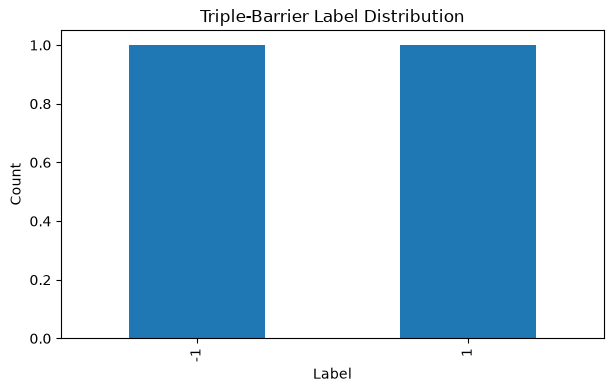

In [32]:
if not labels.empty:
    plt.figure(figsize=(7,4))
    labels["bin"].value_counts().sort_index().plot(kind="bar")
    plt.title("Triple-Barrier Label Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()

In [33]:
print("Data ends:", close.index.max())
print("First CUSUM event:", t_events.min())
print("Last CUSUM event:", t_events.max())

print("First event + 1 day:", t_events.min() + pd.Timedelta(days=1))

Data ends: 2013-09-03 13:49:06.359000
First CUSUM event: 2013-09-03 00:12:57.042000
Last CUSUM event: 2013-09-03 11:47:12.747000
First event + 1 day: 2013-09-04 00:12:57.042000
